# Design benchmark analysis example

This shows how to load and plot the metrics CSV computed by the design benchmark pipeline.

See README for how to run the pipeline.

## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import glob, os, shutil, sys

In [3]:
def remove_constant_columns(df):
    """Removes columns from a Dataframe which only have 1 unique value"""
    for col in df.columns:
        if len(df[col].astype(str).drop_duplicates())==1: # all the same
            df = df.drop(col, axis=1)
    return df

## Analyze


In [6]:
df = pd.read_csv('run1/compiled_metrics.csv', index_col=0)

In [7]:
df.columns

Index(['name', 'lddt', 'inpaint_lddt', 'sampled_mask', 'pdb', 'contigs',
       'length', 'task', 'checkpoint', 'inpaint_str', 'inpaint_seq', 'n_cycle',
       'tmpl_conf', 'num_designs', 'start_num', 'topo_pdb', 'topo_conf',
       'topo_contigs', 'res_translate', 'tie_translate', 'block_rotate',
       'multi_templates', 'multi_tmpl_conf', 'temperature',
       'min_decoding_distance', 'out', 'dump_pdb', 'dump_trb', 'dump_npz',
       'dump_all', 'input_json', 'cautious', 'ref_idx', 'hal_idx', 'idx_rf',
       'inpaint_seq_tensor', 'inpaint_str_tensor', 'outdir', 'prefix',
       'af2_lddt', 'rmsd_af2_des', 'contig_rmsd_af2_des', 'contig_rmsd_af2'],
      dtype='object')

In [8]:
df = remove_constant_columns(df)

In [9]:
df.columns

Index(['name', 'lddt', 'inpaint_lddt', 'tmpl_conf', 'start_num', 'temperature',
       'out', 'cautious', 'outdir', 'prefix', 'af2_lddt', 'rmsd_af2_des',
       'contig_rmsd_af2_des', 'contig_rmsd_af2'],
      dtype='object')

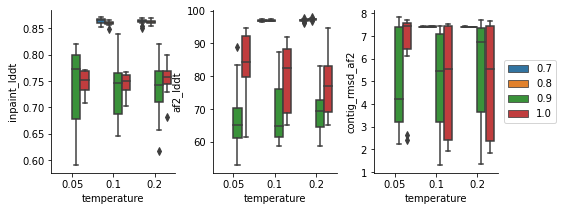

In [10]:
fig, axes = plt.subplots(1,3,figsize=(8,3))
plt.subplots_adjust(wspace=0.3)
for ax,metric in zip(axes.flat, ['inpaint_lddt','af2_lddt','contig_rmsd_af2']):
    sns.boxplot(ax=ax, data=df, y=metric, x='temperature', hue='tmpl_conf')
    ax.legend().set_visible(False)
ax.legend(bbox_to_anchor=(1.01,0.5),loc='center left')
sns.despine()

In [11]:
df

,name,lddt,inpaint_lddt,tmpl_conf,start_num,temperature,out,cautious,outdir,prefix,af2_lddt,rmsd_af2_des,contig_rmsd_af2_des,contig_rmsd_af2
0,run1_rsv5-1_cond8_4,0.858398,0.855469,0.7,4,0.20,run1/run1_rsv5-1_cond8,True,run1,run1_rsv5-1_cond8,97.224059,0.420127,0.196505,7.409054
1,run1_rsv5-1_cond3_0,0.779297,0.731445,1.0,0,0.10,rsv5_1_r1/rsv5_1_r1_cond3,False,rsv5_1_r1,rsv5_1_r1_cond3,65.437064,4.159708,3.579462,3.672715
2,run1_rsv5-1_cond8_3,0.865723,0.863281,0.7,2,0.20,run1/run1_rsv5-1_cond8,True,run1,run1_rsv5-1_cond8,96.937706,0.479209,0.126544,7.377403
3,run1_rsv5-1_cond3_7,0.792969,0.754395,1.0,6,0.10,rsv5_1_r1/rsv5_1_r1_cond3,False,rsv5_1_r1,rsv5_1_r1_cond3,91.489361,22.564263,7.424897,7.440560
4,run1_rsv5-1_cond4_3,0.715332,0.656250,0.9,2,0.20,rsv5_1_r1/rsv5_1_r1_cond4,False,rsv5_1_r1,rsv5_1_r1_cond4,83.176356,14.837950,7.443390,7.546609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,run1_rsv5-1_cond6_6,0.863281,0.859863,0.7,6,0.10,run1/run1_rsv5-1_cond6,True,run1,run1_rsv5-1_cond6,96.717621,0.702699,0.183506,7.389846
96,run1_rsv5-1_cond6_1,0.858398,0.853516,0.7,0,0.10,run1/run1_rsv5-1_cond6,True,run1,run1_rsv5-1_cond6,96.460645,0.564417,0.217790,7.420650
97,run1_rsv5-1_cond1_5,0.759766,0.721191,1.0,4,0.05,rsv5_1_r1/rsv5_1_r1_cond1,False,rsv5_1_r1,rsv5_1_r1_cond1,94.711916,22.289398,7.415627,7.452698
98,run1_rsv5-1_cond1_2,0.807129,0.770508,1.0,2,0.05,rsv5_1_r1/rsv5_1_r1_cond1,False,rsv5_1_r1,rsv5_1_r1_cond1,93.109287,22.357737,7.373741,7.419032
